# <center>EXPLORATORY DATA ANALYSIS - AIRPORT CHECK-IN DATA</center>

In [1]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading data
df = pd.read_csv('../data/raw/checkin_queue_synthetic_2019_2025v2.csv')

In [3]:
# Evaluating the shape of the data
print(f"Data Shape: {df.shape}")

Data Shape: (25168, 22)


In [4]:
# Initial Overview (Head and Tail)
df.head()

,Date,Start_Time,End_time,Sector,Airline,Start_Line,End_line,Pax_In_Line,Service_Start,Service_End,...,Luggage_In,Luggage_Out,Line_Type,Queue_Agent,PAX_Left,Flight_Cancelled,Heavy_Flow,Continuous_Flow,Carousel_Stoped,Year
0,2019-11-01,16:00:00,17:00:00,Domestic,Ariline 2,16:37:39,16:50:30,13.0,16:50:33,16:57:49,...,10,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019
1,2019-12-09,16:00:00,17:00:00,Domestic,Ariline 1,16:22:02,16:22:34,1.0,16:22:37,16:28:05,...,4,3.0,CK,NaN,NaN,NaN,NaN,NaN,NaN,2019
2,2019-07-05,22:00:00,23:00:00,International,Ariline 10,22:53:55,23:22:16,9.0,23:22:20,23:30:23,...,3,2.0,CK,NaN,NaN,NaN,NaN,NaN,NaN,2019
3,2019-05-11,11:00:00,12:00:00,Domestic,Ariline 1,11:18:01,11:34:07,10.0,11:34:10,11:37:11,...,4,3.0,BD,X,NaN,NaN,NaN,NaN,NaN,2019
4,2019-11-09,17:00:00,18:00:00,Domestic,Ariline 2,17:05:51,17:14:21,0.0,17:14:23,17:19:43,...,1,1.0,PM,X,NaN,NaN,NaN,NaN,NaN,2019


In [5]:
df.tail()

,Date,Start_Time,End_time,Sector,Airline,Start_Line,End_line,Pax_In_Line,Service_Start,Service_End,...,Luggage_In,Luggage_Out,Line_Type,Queue_Agent,PAX_Left,Flight_Cancelled,Heavy_Flow,Continuous_Flow,Carousel_Stoped,Year
25163,2025-01-05,22:00:00,23:00:00,International,Ariline 9,22:43:14,22:43:14,0.0,22:43:14,22:51:09,...,3,2.0,CK,NaN,NaN,NaN,NaN,X,NaN,2025
25164,2025-07-08,20:00:00,21:00:00,International,Ariline 4,21:06:05,21:27:49,6.0,21:27:52,21:30:13,...,4,2.0,BD,NaN,NaN,NaN,NaN,NaN,NaN,2025
25165,2025-02-06,20:00:00,21:00:00,International,Ariline 1,20:19:42,20:38:20,1.0,20:38:25,20:47:13,...,6,3.0,CK,NaN,NaN,NaN,NaN,NaN,NaN,2025
25166,2025-08-11,22:00:00,23:00:00,International,Ariline 10,22:36:40,22:41:34,0.0,22:41:39,22:43:30,...,3,2.0,BD,X,NaN,NaN,NaN,NaN,NaN,2025
25167,2025-08-09,09:00:00,10:00:00,Domestic,Ariline 3,09:34:26,09:35:33,1.0,09:35:37,09:39:29,...,2,1.0,CK,NaN,NaN,NaN,NaN,NaN,NaN,2025


In [6]:
# Evaluating datatypes and Basic Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25168 entries, 0 to 25167
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              25168 non-null  object 
 1   Start_Time        25168 non-null  object 
 2   End_time          25168 non-null  object 
 3   Sector            25168 non-null  object 
 4   Airline           25168 non-null  object 
 5   Start_Line        25168 non-null  object 
 6   End_line          25168 non-null  object 
 7   Pax_In_Line       25168 non-null  float64
 8   Service_Start     25168 non-null  object 
 9   Service_End       25168 non-null  object 
 10  PAX_Served        25168 non-null  int64  
 11  Counters          25168 non-null  int64  
 12  Luggage_In        25168 non-null  int64  
 13  Luggage_Out       25168 non-null  float64
 14  Line_Type         20870 non-null  object 
 15  Queue_Agent       10621 non-null  object 
 16  PAX_Left          307 non-null    object

In [7]:
# Evaluating Missing Values
missing_values = df.isnull().sum()
print("Missing Values in each column:\n", missing_values)

Missing Values in each column:
 Date                    0
Start_Time              0
End_time                0
Sector                  0
Airline                 0
Start_Line              0
End_line                0
Pax_In_Line             0
Service_Start           0
Service_End             0
PAX_Served              0
Counters                0
Luggage_In              0
Luggage_Out             0
Line_Type            4298
Queue_Agent         14547
PAX_Left            24861
Flight_Cancelled    25098
Heavy_Flow          24669
Continuous_Flow     22687
Carousel_Stoped     24280
Year                    0
dtype: int64


In [8]:
# Percentage of missing values
missing_percentage = (missing_values / len(df)) * 100
print("Percentage of Missing Values in each column:\n", missing_percentage)

Percentage of Missing Values in each column:
 Date                 0.000000
Start_Time           0.000000
End_time             0.000000
Sector               0.000000
Airline              0.000000
Start_Line           0.000000
End_line             0.000000
Pax_In_Line          0.000000
Service_Start        0.000000
Service_End          0.000000
PAX_Served           0.000000
Counters             0.000000
Luggage_In           0.000000
Luggage_Out          0.000000
Line_Type           17.077241
Queue_Agent         57.799587
PAX_Left            98.780197
Flight_Cancelled    99.721869
Heavy_Flow          98.017324
Continuous_Flow     90.142244
Carousel_Stoped     96.471710
Year                 0.000000
dtype: float64


In [9]:
# Descriptive Analytics
df.describe()

,Pax_In_Line,PAX_Served,Counters,Luggage_In,Luggage_Out,Year
count,25168.000000,25168.000000,25168.000000,25168.000000,25168.000000,25168.000000
mean,4.369835,1.772648,5.356882,3.101041,1.806818,2022.446281
std,6.181959,1.015771,1.850370,1.868911,1.270170,2.036690
min,0.000000,1.000000,1.000000,0.000000,0.000000,2019.000000
25%,0.000000,1.000000,4.000000,2.000000,1.000000,2021.000000
50%,2.000000,1.000000,5.000000,3.000000,2.000000,2023.000000
75%,6.000000,2.000000,7.000000,4.000000,2.000000,2024.000000
max,55.000000,12.000000,12.000000,25.000000,15.000000,2025.000000


In [10]:
# Categorical Variable Analysis
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
time_cols = ['Date', 'Start_Time', 'End_time', 'Start_Line', 'End_line', 'Service_Start', 'Service_End']
categorical_cols = [col for col in categorical_cols if col not in time_cols]

for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Value counts:")
    print(df[col].value_counts().head(10))


Sector:
  Unique values: 2
  Value counts:
Sector
Domestic         17951
International     7217
Name: count, dtype: int64

Airline:
  Unique values: 10
  Value counts:
Airline
Ariline 3     6033
Ariline 1     5806
Ariline 2     5358
Ariline 4     2152
Ariline 5     1737
Ariline 6     1504
Ariline 7      842
Ariline 9      790
Ariline 10     607
Ariline 8      339
Name: count, dtype: int64

Line_Type:
  Unique values: 9
  Value counts:
Line_Type
CK     12979
 BD     5326
 PR     1036
 PM      863
 BE      401
BD       206
 OS       27
PM        20
PR        12
Name: count, dtype: int64

Queue_Agent:
  Unique values: 1
  Value counts:
Queue_Agent
X    10621
Name: count, dtype: int64

PAX_Left:
  Unique values: 1
  Value counts:
PAX_Left
X    307
Name: count, dtype: int64

Flight_Cancelled:
  Unique values: 1
  Value counts:
Flight_Cancelled
X    70
Name: count, dtype: int64

Heavy_Flow:
  Unique values: 1
  Value counts:
Heavy_Flow
X    499
Name: count, dtype: int64

Continuous_Flow:
  

In [11]:
# Date and Time Variable Analysis
df['Date_parsed'] = pd.to_datetime(df['Date'], errors='coerce')

print(f"\nDate Range: {df['Date_parsed'].min()} to {df['Date_parsed'].max()}")
print(f"Total Days Covered: {(df['Date_parsed'].max() - df['Date_parsed'].min()).days}")


Date Range: 2019-01-03 00:00:00 to 2025-12-12 00:00:00
Total Days Covered: 2535


In [12]:
df.head()

,Date,Start_Time,End_time,Sector,Airline,Start_Line,End_line,Pax_In_Line,Service_Start,Service_End,...,Luggage_Out,Line_Type,Queue_Agent,PAX_Left,Flight_Cancelled,Heavy_Flow,Continuous_Flow,Carousel_Stoped,Year,Date_parsed
0,2019-11-01,16:00:00,17:00:00,Domestic,Ariline 2,16:37:39,16:50:30,13.0,16:50:33,16:57:49,...,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019,2019-11-01
1,2019-12-09,16:00:00,17:00:00,Domestic,Ariline 1,16:22:02,16:22:34,1.0,16:22:37,16:28:05,...,3.0,CK,NaN,NaN,NaN,NaN,NaN,NaN,2019,2019-12-09
2,2019-07-05,22:00:00,23:00:00,International,Ariline 10,22:53:55,23:22:16,9.0,23:22:20,23:30:23,...,2.0,CK,NaN,NaN,NaN,NaN,NaN,NaN,2019,2019-07-05
3,2019-05-11,11:00:00,12:00:00,Domestic,Ariline 1,11:18:01,11:34:07,10.0,11:34:10,11:37:11,...,3.0,BD,X,NaN,NaN,NaN,NaN,NaN,2019,2019-05-11
4,2019-11-09,17:00:00,18:00:00,Domestic,Ariline 2,17:05:51,17:14:21,0.0,17:14:23,17:19:43,...,1.0,PM,X,NaN,NaN,NaN,NaN,NaN,2019,2019-11-09


In [13]:
# Extracting temporal features
df['Year'] = df['Date_parsed'].dt.year
df['Month'] = df['Date_parsed'].dt.month
df['Day_of_Week'] = df['Date_parsed'].dt.day_name()
df['Day'] = df['Date_parsed'].dt.day
df['Hour'] = pd.to_datetime(df['Start_Time'], format='%H:%M:%S', errors='coerce').dt.hour
df['Quarter'] = df['Date_parsed'].dt.quarter
df['Year_Month'] = df['Date_parsed'].dt.to_period('M')

In [14]:
# Records by Year
print("\nRecords by Year:")
print(df['Year'].value_counts().sort_index())


Records by Year:
Year
2019    4160
2020    1040
2021    2080
2022    4160
2023    4368
2024    4576
2025    4784
Name: count, dtype: int64


In [15]:
# Records by Month
print("\nRecords by Month:")
print(df['Month'].value_counts().sort_index())


Records by Month:
Month
1     1768
2     1843
3     1579
4     2199
5     1970
6     2585
7     1782
8     2282
9     2311
10    2371
11    2040
12    2438
Name: count, dtype: int64


In [16]:
# Records by day of the week
print("\nRecords by Day of the Week (0=Monday, 6=Sunday):")
print(df['Day_of_Week'].value_counts().sort_index())


Records by Day of the Week (0=Monday, 6=Sunday):
Day_of_Week
Friday       3641
Monday       3820
Saturday     3555
Sunday       3582
Thursday     3493
Tuesday      3620
Wednesday    3457
Name: count, dtype: int64


In [17]:
# Records by hour of the day
print("\nRecords by Hour of the Day:")
print(df['Hour'].value_counts().sort_index())


Records by Hour of the Day:
Hour
0       54
4       57
6       49
7      609
8     1129
9      878
10    1894
11    1398
12    2331
13    2066
14    2062
15    2444
16    2258
17    1514
18    1756
19    1265
20    2092
21     528
22     721
23      63
Name: count, dtype: int64


In [18]:
# Duplicated Rows Analysis
duplicated = df.duplicated().sum()
print(f"\nNumber of duplicated rows: {duplicated}")

if duplicated > 0:
    print("Duplicated Rows Sample:")
    print(df[df.duplicated(keep=False)].head())


Number of duplicated rows: 9051
Duplicated Rows Sample:
         Date Start_Time  End_time         Sector     Airline Start_Line  \
0  2019-11-01   16:00:00  17:00:00       Domestic   Ariline 2   16:37:39   
2  2019-07-05   22:00:00  23:00:00  International  Ariline 10   22:53:55   
3  2019-05-11   11:00:00  12:00:00       Domestic   Ariline 1   11:18:01   
5  2019-10-02   13:00:00  14:00:00       Domestic   Ariline 3   13:01:38   
6  2019-05-12   10:00:00  11:00:00       Domestic   Ariline 3   10:06:13   

   End_line  Pax_In_Line Service_Start Service_End  ...  Continuous_Flow  \
0  16:50:30         13.0      16:50:33    16:57:49  ...              NaN   
2  23:22:16          9.0      23:22:20    23:30:23  ...              NaN   
3  11:34:07         10.0      11:34:10    11:37:11  ...              NaN   
5  13:03:21          4.0      13:03:26    13:04:29  ...              NaN   
6  10:06:13          0.0      10:06:13    10:08:36  ...                X   

   Carousel_Stoped  Year  Dat

In [19]:
# Data Quality Checks
print("\nData Quality Checks:")
# Checking for negative values 
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("\nNegative Values in Numeric Columns:\n")
for col in numeric_cols:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f"  {col}: {negative_count} negative values")
    else:
        print(f"  {col}: No negative values")

# Checking for zero values
print("\nZero Values in Numeric Columns:\n")
for col in numeric_cols:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f"  {col}: {zero_count} zero values")
    else:
        print(f"  {col}: No zero values")

# Checking for counters range
print("\nCounter Statistics\n")
print(f"Minimun Counters: {df['Counters'].min()}")
print(f"Maximum Counters: {df['Counters'].max()}")
print(f"Mean Counters: {df['Counters'].mean()}")
print(f"Zero Counters: {(df['Counters'] == 0).sum()}")



Data Quality Checks:

Negative Values in Numeric Columns:

  Pax_In_Line: No negative values
  PAX_Served: No negative values
  Counters: No negative values
  Luggage_In: No negative values
  Luggage_Out: No negative values
  Year: No negative values
  Month: No negative values
  Day: No negative values
  Hour: No negative values
  Quarter: No negative values

Zero Values in Numeric Columns:

  Pax_In_Line: 6889 zero values
  PAX_Served: No zero values
  Counters: No zero values
  Luggage_In: 35 zero values
  Luggage_Out: 1957 zero values
  Year: No zero values
  Month: No zero values
  Day: No zero values
  Hour: 54 zero values
  Quarter: No zero values

Counter Statistics

Minimun Counters: 1
Maximum Counters: 12
Mean Counters: 5.356881754609027
Zero Counters: 0


In [20]:
# Outlier Detection Using IQR Method
numeric_cols_outlier = ['Pax_In_Line', 'PAX_Served', 'Counters', 'Luggage_In', 'Luggage_Out']

for col in numeric_cols_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"\n{col}:")
    print(f"  Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers count: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
   
   # printing the outliers range
    if len(outliers) > 0:
        print(f"  Outlier Range: [{outliers[col].min()}, {outliers[col].max()}]")


Pax_In_Line:
  Q1: 0.0, Q3: 6.0, IQR: 6.0
  Bounds: [-9.00, 15.00]
  Outliers count: 1532 (6.09%)
  Outlier Range: [16.0, 55.0]

PAX_Served:
  Q1: 1.0, Q3: 2.0, IQR: 1.0
  Bounds: [-0.50, 3.50]
  Outliers count: 1909 (7.59%)
  Outlier Range: [4, 12]

Counters:
  Q1: 4.0, Q3: 7.0, IQR: 3.0
  Bounds: [-0.50, 11.50]
  Outliers count: 11 (0.04%)
  Outlier Range: [12, 12]

Luggage_In:
  Q1: 2.0, Q3: 4.0, IQR: 2.0
  Bounds: [-1.00, 7.00]
  Outliers count: 750 (2.98%)
  Outlier Range: [8, 25]

Luggage_Out:
  Q1: 1.0, Q3: 2.0, IQR: 1.0
  Bounds: [-0.50, 3.50]
  Outliers count: 2224 (8.84%)
  Outlier Range: [4.0, 15.0]



Correlation Matrix:
              Pax_In_Line  PAX_Served  Counters  Luggage_In  Luggage_Out
Pax_In_Line     1.000000    0.068594  0.042455    0.112831     0.075476
PAX_Served      0.068594    1.000000  0.018838    0.744467     0.631484
Counters        0.042455    0.018838  1.000000    0.012391    -0.051375
Luggage_In      0.112831    0.744467  0.012391    1.000000     0.836229
Luggage_Out     0.075476    0.631484 -0.051375    0.836229     1.000000


,Pax_In_Line,PAX_Served,Counters,Luggage_In,Luggage_Out
Pax_In_Line,1.000,0.069,0.042,0.113,0.075
PAX_Served,0.069,1.000,0.019,0.744,0.631
Counters,0.042,0.019,1.000,0.012,-0.051
Luggage_In,0.113,0.744,0.012,1.000,0.836
Luggage_Out,0.075,0.631,-0.051,0.836,1.000


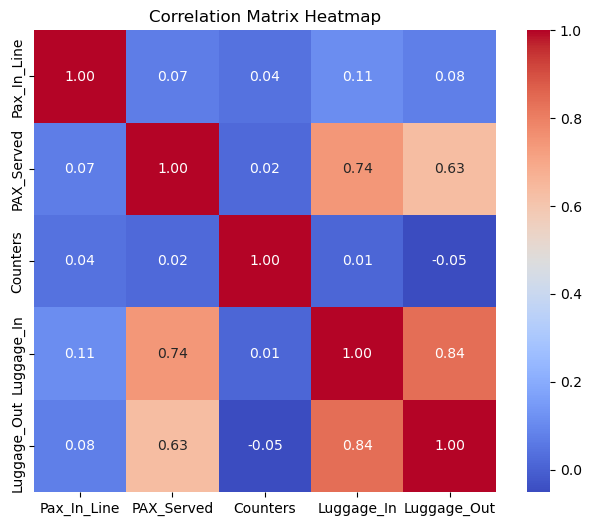

In [21]:
# Correlation Analysis
numeric_df = df[['Pax_In_Line', 'PAX_Served', 'Counters', 'Luggage_In', 'Luggage_Out']].copy()

correlation_matrix = numeric_df.corr()
print("\nCorrelation Matrix:\n", correlation_matrix)
display(correlation_matrix.round(3))

# Visualization of Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [22]:
print("\n--- Strong Correlations (|r| > 0.5) ---")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            print(f"{correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {corr_value:.3f}")


--- Strong Correlations (|r| > 0.5) ---
PAX_Served <-> Luggage_In: 0.744
PAX_Served <-> Luggage_Out: 0.631
Luggage_In <-> Luggage_Out: 0.836


# <center>Visualizations</center>

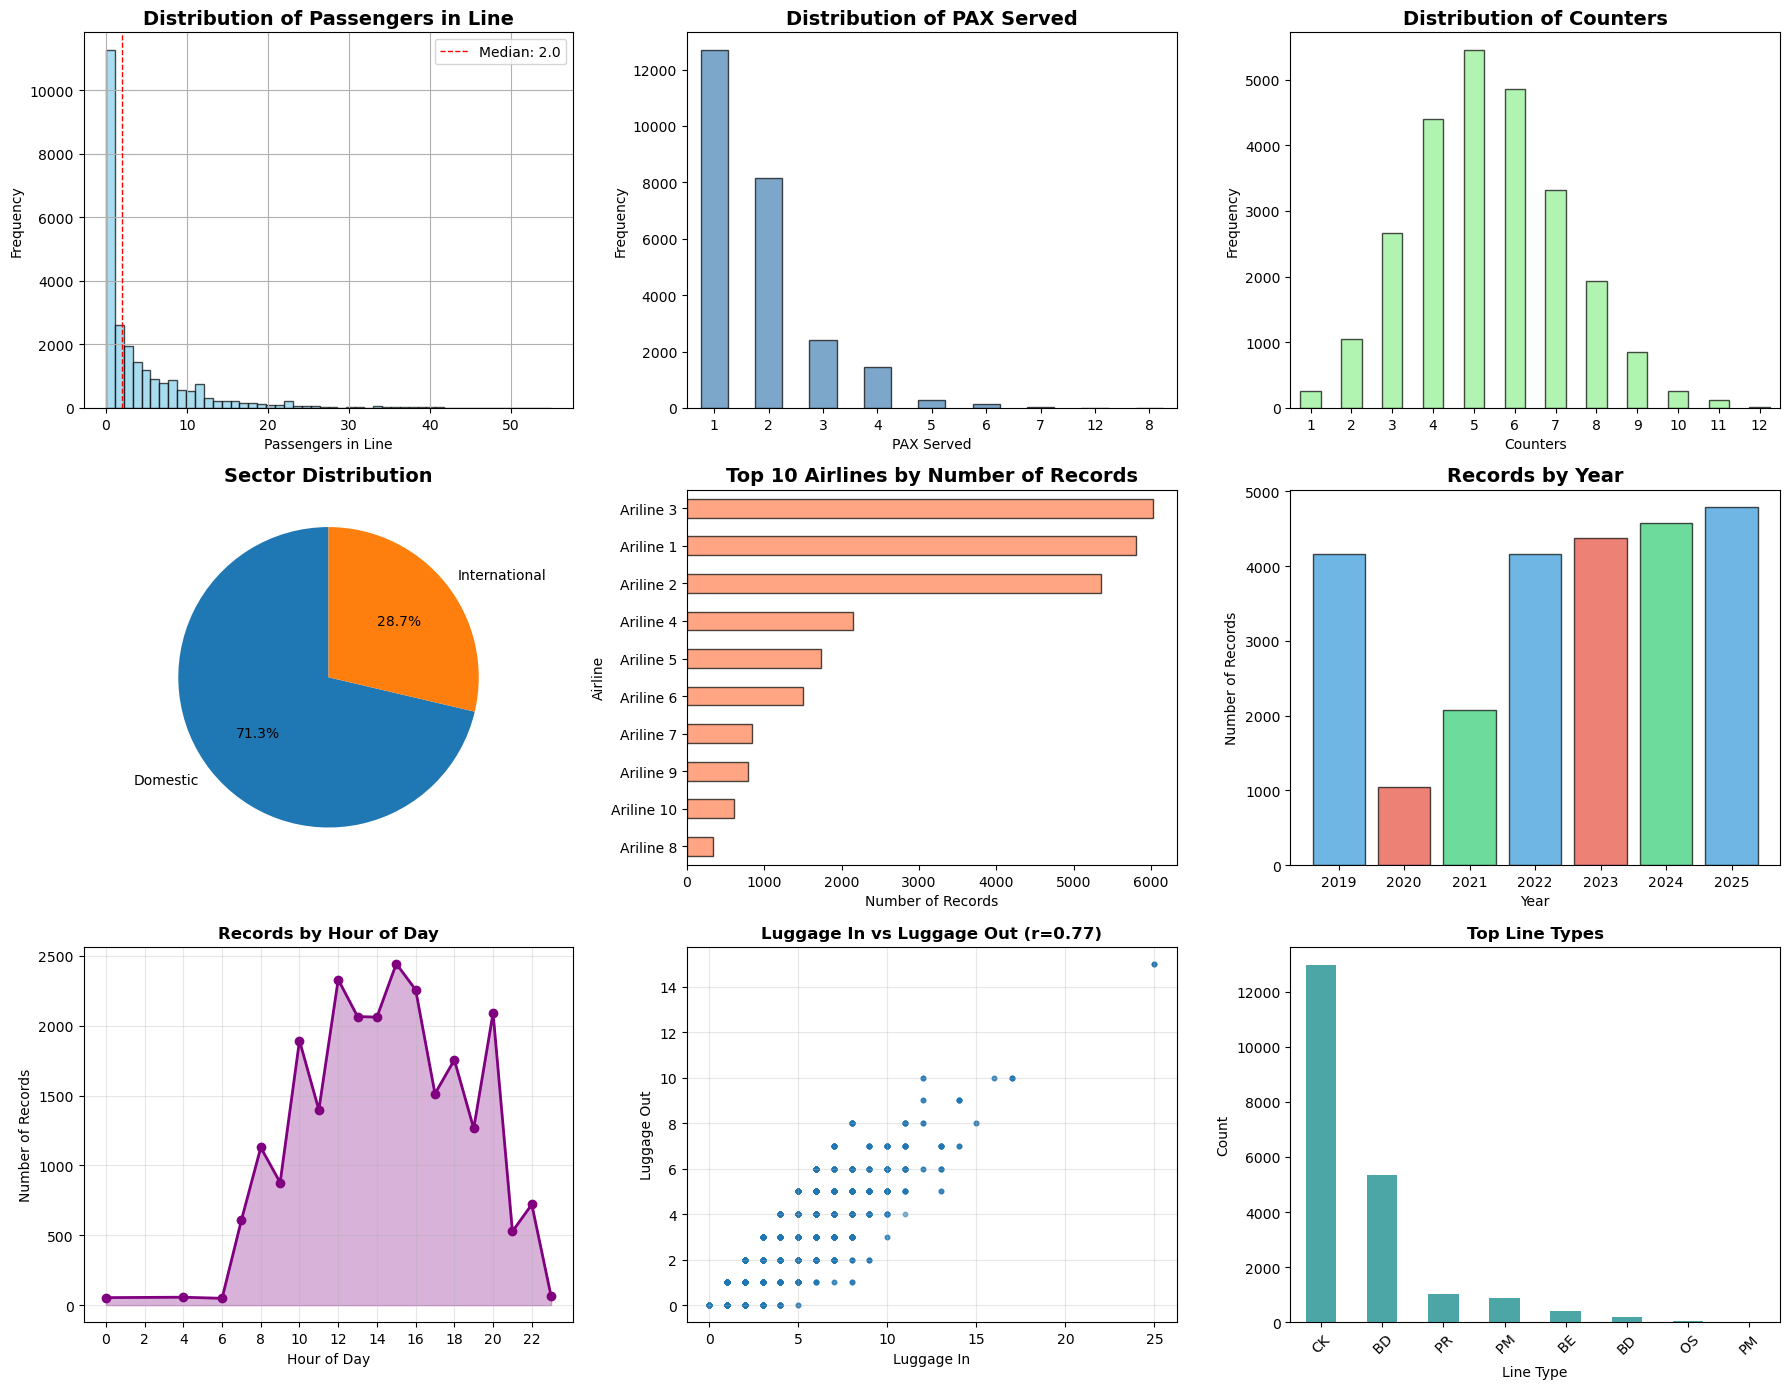

✓ Main visualization saved as 'eda_visualizations.png'


In [23]:
# Main EDA Visualizations
fig = plt.figure(figsize=(18,14))

# Distributions of Passengers in Line
ax1 = plt.subplot(3,3,1)
df['Pax_In_Line'].hist(bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Passengers in Line')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Passengers in Line', fontweight='bold', fontsize=14)
ax1.axvline(df['Pax_In_Line'].median(), color='red', linestyle='--', linewidth=1, label=f'Median: {df["Pax_In_Line"].median():.1f}')
ax1.legend()

# Distribution of PAX Served
ax2 = plt.subplot(3,3,2)
df['PAX_Served'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('PAX Served')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of PAX Served', fontweight='bold', fontsize=14)
ax2.tick_params(axis='x', rotation=0)

# Distribution of Counters
ax3 = plt.subplot(3,3,3)
df['Counters'].value_counts().sort_index().plot(kind='bar', color='lightgreen', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Counters')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Counters', fontweight='bold', fontsize=14)
ax3.tick_params(axis='x', rotation=0)

#Increasing the ploting area for better visibility
plt.subplots_adjust(hspace=0.4, wspace=0.4)

#Sector Distribuition
ax4 = plt.subplot(3,3,4)
sector_counts = df['Sector'].value_counts()
colors_sector = ['#1f77b4', '#ff7f0e']
ax4.pie(sector_counts, labels=sector_counts.index, autopct='%1.1f%%', startangle=90, colors=colors_sector)
ax4.set_title('Sector Distribution', fontweight='bold', fontsize=14)

# Top 10 airlines
ax5 = plt.subplot(3,3,5)
top_airlines = df['Airline'].value_counts().head(10)
top_airlines.plot(kind='barh', color='coral', edgecolor='black', alpha=0.7)
ax5.set_xlabel('Number of Records')
ax5.set_ylabel('Airline')
ax5.set_title('Top 10 Airlines by Number of Records', fontweight='bold', fontsize=14)
ax5.invert_yaxis()

# Records by Year
ax6 = plt.subplot(3,3,6)
year_counts = df['Year'].value_counts().sort_index()
ax6.bar(year_counts.index, year_counts.values, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.7)
ax6.set_xlabel('Year')
ax6.set_ylabel('Number of Records')
ax6.set_title('Records by Year', fontweight='bold', fontsize=14)
ax6.set_xticks(year_counts.index)

#Increasing the ploting area for better visibility
plt.subplots_adjust(hspace=0.4, wspace=0.4)

# Records by Hour of the Day
ax7 = plt.subplot(3, 3, 7)
hour_counts = df['Hour'].value_counts().sort_index()
ax7.plot(hour_counts.index, hour_counts.values, marker='o', linewidth=2, 
         markersize=6, color='purple')
ax7.fill_between(hour_counts.index, hour_counts.values, alpha=0.3, color='purple')
ax7.set_xlabel('Hour of Day')
ax7.set_ylabel('Number of Records')
ax7.set_title('Records by Hour of Day', fontweight='bold')
ax7.grid(True, alpha=0.3)
ax7.set_xticks(range(0, 24, 2))

# Luggage In vs Luggage Out
ax8 = plt.subplot(3, 3, 8)
ax8.scatter(df['Luggage_In'], df['Luggage_Out'], alpha=0.3, s=10)
ax8.set_xlabel('Luggage In')
ax8.set_ylabel('Luggage Out')
ax8.set_title('Luggage In vs Luggage Out (r=0.77)', fontweight='bold')
ax8.grid(True, alpha=0.3)

# Linetype Distribution
ax9 = plt.subplot(3, 3, 9)
line_type_counts = df['Line_Type'].value_counts().head(8)
line_type_counts.plot(kind='bar', color='teal', alpha=0.7)
ax9.set_xlabel('Line Type')
ax9.set_ylabel('Count')
ax9.set_title('Top Line Types', fontweight='bold')
ax9.tick_params(axis='x', rotation=45)

# saving figure in the reports/figures folder
plt.tight_layout()
plt.savefig('../reports/figures/eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Main visualization saved as 'eda_visualizations.png'")

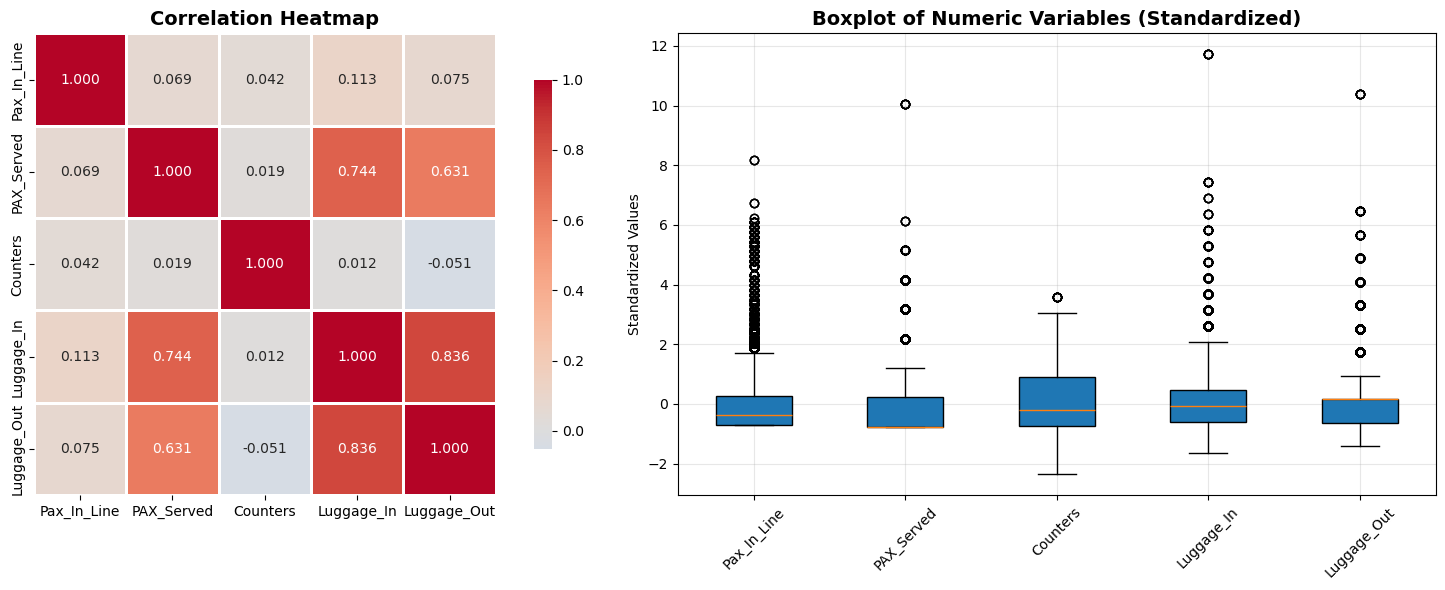

✓ Correlation and boxplot saved as 'correlation_boxplot.png'


In [24]:
# Figure 2: Correlation Heatmap and Boxplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title('Correlation Heatmap', fontweight='bold', fontsize=14)

# Boxplot for numeric variables (standardized)
numeric_df_normalized = (numeric_df - numeric_df.mean()) / numeric_df.std()
axes[1].boxplot([numeric_df_normalized[col].dropna() for col in numeric_df.columns],
                labels=numeric_df.columns, patch_artist=True)
axes[1].set_ylabel('Standardized Values')
axes[1].set_title('Boxplot of Numeric Variables (Standardized)', fontweight='bold', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/correlation_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation and boxplot saved as 'correlation_boxplot.png'")

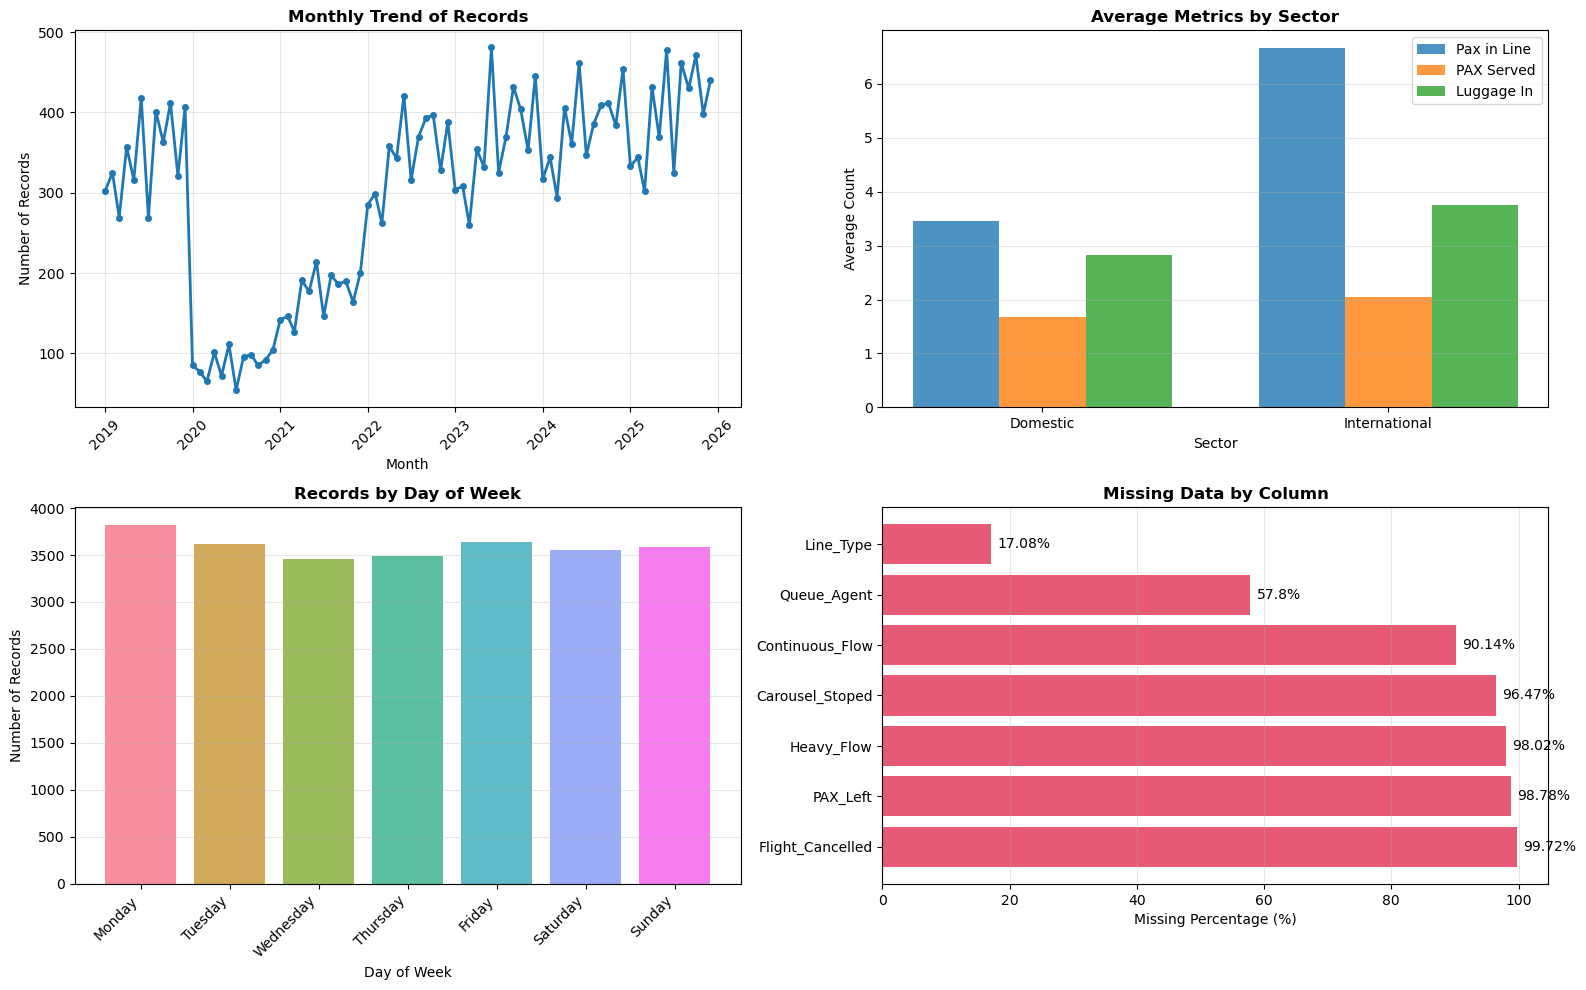

✓ Time series analysis saved as 'time_series_analysis.png'


In [25]:
# Figure 3: Time Serie Analysis
fig, axes = plt.subplots(2,2, figsize=(16,10))

# 1. Monthly trend Analysis
monthly_data_plot = df.groupby(df['Date_parsed'].dt.to_period('M')).size()
monthly_data_plot.index = monthly_data_plot.index.to_timestamp()
axes[0, 0].plot(monthly_data_plot.index, monthly_data_plot.values, linewidth=2, marker='o', markersize=4)
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Number of Records')
axes[0, 0].set_title('Monthly Trend of Records', fontweight='bold', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Average Passengers by sector
sector_stats = df.groupby('Sector').agg({
    'Pax_In_Line': 'mean',
    'PAX_Served': 'mean',
    'Luggage_In': 'mean'
}).round(2)

x = np.arange(len(sector_stats.index))
width = 0.25
axes[0, 1].bar(x - width, sector_stats['Pax_In_Line'], width, label='Pax in Line', alpha=0.8)
axes[0, 1].bar(x, sector_stats['PAX_Served'], width, label='PAX Served', alpha=0.8)
axes[0, 1].bar(x + width, sector_stats['Luggage_In'], width, label='Luggage In', alpha=0.8)
axes[0, 1].set_xlabel('Sector')
axes[0, 1].set_ylabel('Average Count')
axes[0, 1].set_title('Average Metrics by Sector', fontweight='bold', fontsize=12)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(sector_stats.index)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Day of Week Pattern
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['Day_of_Week'].value_counts().reindex(day_order).fillna(0)
axes[1, 0].bar(range(len(day_counts)), day_counts.values, 
               color=sns.color_palette("husl", 7), alpha=0.8)
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Number of Records')
axes[1, 0].set_title('Records by Day of Week', fontweight='bold', fontsize=12)
axes[1, 0].set_xticks(range(len(day_counts)))
axes[1, 0].set_xticklabels(day_order, rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3, axis='y')

#4. Missing Dates Visualizations
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]
missing_pct = (missing_data / len(df) * 100).round(2)

axes[1, 1].barh(range(len(missing_pct)), missing_pct.values, color='crimson', alpha=0.7)
axes[1, 1].set_yticks(range(len(missing_pct)))
axes[1, 1].set_yticklabels(missing_pct.index)
axes[1, 1].set_xlabel('Missing Percentage (%)')
axes[1, 1].set_title('Missing Data by Column', fontweight='bold', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='x')

# Add percentage labels
for i, v in enumerate(missing_pct.values):
    axes[1, 1].text(v + 1, i, f'{v}%', va='center')

plt.tight_layout()
plt.savefig('../reports/figures/time_series_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Time series analysis saved as 'time_series_analysis.png'")